### 1. 데이터 불러오기

In [1]:
import pandas as pd
import FinanceDataReader as fdr

# 삼성전자
STOCK_CODE = '005930'

stock = fdr.DataReader(STOCK_CODE)

### 2. 데이터 전처리

In [2]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
# 스케일을 적용할 column을 정의합니다.
scale_cols = ['Open', 'High', 'Low', 'Close', 'Volume']
# 스케일 후 columns
scaled = scaler.fit_transform(stock[scale_cols])

df = pd.DataFrame(scaled, columns=scale_cols)

### 3. Train / Test 분할

In [3]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(df.drop('Close', axis=1), df['Close'], test_size=0.2, random_state=0, shuffle=False)

### 4. Dataset 구성

In [4]:
import tensorflow as tf

def windowed_dataset(series, window_size, batch_size, shuffle):
    series = tf.expand_dims(series, axis=-1)
    ds = tf.data.Dataset.from_tensor_slices(series)
    ds = ds.window(window_size + 1, shift=1, drop_remainder=True)
    ds = ds.flat_map(lambda w: w.batch(window_size + 1))
    if shuffle:
        ds = ds.shuffle(1000)
    ds = ds.map(lambda w: (w[:-1], w[-1]))
    return ds.batch(batch_size).prefetch(1)

WINDOW_SIZE=20
BATCH_SIZE=32

# trian_data는 학습용 데이터셋, test_data는 검증용 데이터셋 입니다.
train_data = windowed_dataset(y_train, WINDOW_SIZE, BATCH_SIZE, True)
test_data = windowed_dataset(y_test, WINDOW_SIZE, BATCH_SIZE, False)

### 5. 모델

In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Conv1D, Lambda
from tensorflow.keras.losses import Huber
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint


model = Sequential([
    # 1차원 feature map 생성
    Conv1D(filters=32, kernel_size=5,
           padding="causal",
           activation="relu",
           input_shape=[WINDOW_SIZE, 1]),
    # LSTM
    LSTM(16, activation='tanh'),
    Dense(16, activation="relu"),
    Dense(1),
])

C:\Users\조영서\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
# Sequence 학습에 비교적 좋은 퍼포먼스를 내는 Huber()를 사용합니다.
loss = Huber()
optimizer = Adam(0.0005)
model.compile(loss=Huber(), optimizer=optimizer, metrics=['mse'])

In [7]:
import os
from keras.callbacks import EarlyStopping, ModelCheckpoint

# earlystopping은 10번 epoch통안 val_loss 개선이 없다면 학습을 멈춥니다.
earlystopping = EarlyStopping(monitor='val_loss', patience=10)

# val_loss 기준 체크포인터도 생성합니다.
filename = os.path.join('tmp', 'checkpointer.weights.h5')
checkpoint = ModelCheckpoint(filename,
                             save_weights_only=True,
                             save_best_only=True,
                             monitor='val_loss',
                             verbose=1)

In [8]:
history = model.fit(train_data,
                    validation_data=(test_data),
                    epochs=50,
                    callbacks=[checkpoint, earlystopping])

Epoch 1/50
    144/Unknown 2s 4ms/step - loss: 3.8137e-04 - mse: 7.6273e-04

c:\Program Files\Python310\Lib\contextlib.py:155: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)



Epoch 1: val_loss improved from inf to 0.00225, saving model to tmp\checkpointer.weights.h5
150/150 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 3.7186e-04 - mse: 7.4372e-04 - val_loss: 0.0022 - val_mse: 0.0045
Epoch 2/50
147/150 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.3795e-05 - mse: 4.7591e-05
Epoch 2: val_loss improved from 0.00225 to 0.00160, saving model to tmp\checkpointer.weights.h5
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 2.4477e-05 - mse: 4.8954e-05 - val_loss: 0.0016 - val_mse: 0.0032
Epoch 3/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.3029e-05 - mse: 4.6059e-05
Epoch 3: val_loss did not improve from 0.00160
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 2.3174e-05 - mse: 4.6348e-05 - val_loss: 0.0021 - val_mse: 0.0042
Epoch 4/50
141/150 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.7024e-05 - mse: 3.4048e-05
Epoch 4: val_loss did not improve from 0.00160
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.8595e-05 - mse: 3.7189e-05 - val_loss: 0.0020 - val_ms

In [9]:
model.load_weights(filename)

pred = model.predict(test_data)

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


### 6. 예측 데이터 시각화

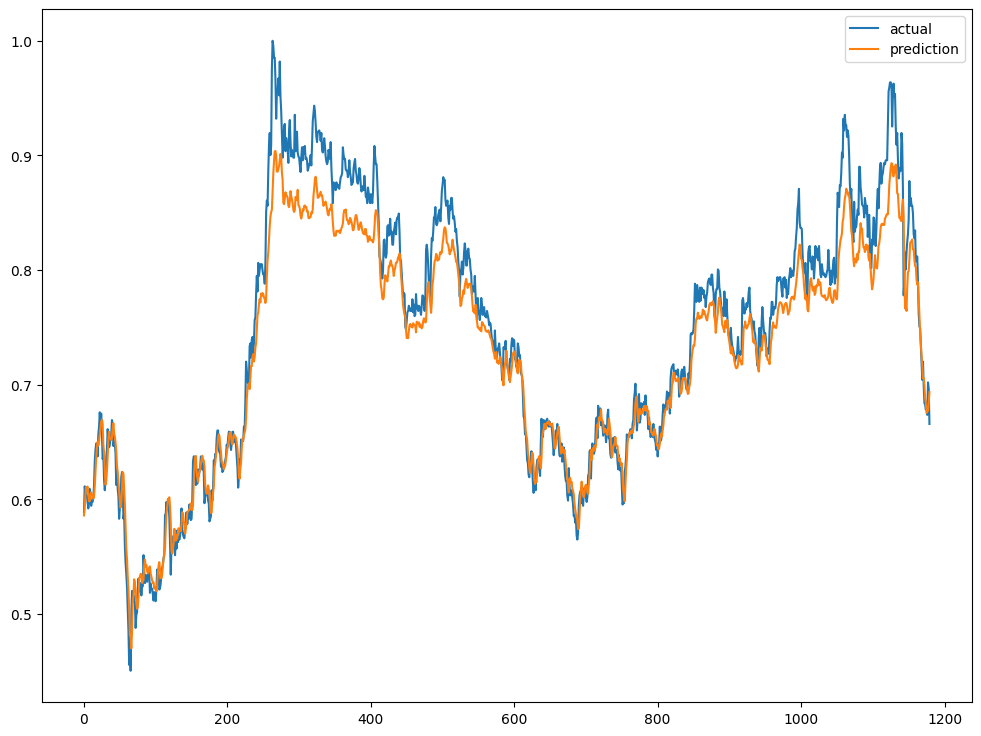

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

plt.figure(figsize=(12, 9))
plt.plot(np.asarray(y_test)[20:], label='actual')
plt.plot(pred, label='prediction')
plt.legend()
plt.show()